In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

# Imports

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

from datetime import datetime
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd
import h3
from shapely import wkt
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Polygon


/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


In [3]:
customer_name = "Cadent"
start_date = "2026-04-23"
end_date = "2026-04-24"

## Get the surveys

In [4]:
output_log = "="*20+'\n'
output_log = f'Starting the process for {customer_name}  \n '
output_log += f'Process started at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n'
#Add current date to the output log as a header
output_log += "="*20+'\n'
#Query the data from the EU2 Database
a = Query(get_users(customer_name, '#UserList'))
b = Query(get_surveys('#UserList',start_date = start_date,end_date = end_date))
a.set_child(b)
current_data = a.execute(EU2_Conn)
print("Number of surveys: ", len(current_data))

Number of surveys:  91


## Get the FOV of the survey

In [5]:
query = f"""SELECT 
            SA.SurveyId as SurveyId,
            SA.ExternalId as BoundaryName,
            SR.FieldOfView.STAsText() as SurveyFOV
            FROM SurveyArea SA
            JOIN SurveyResult SR ON SA.SurveyId = SR.SurveyId
            WHERE SA.SurveyId IN (SELECT SurveyId FROM #TempSurvey)"""
current_data.db.set_query(query)
surveyarea =current_data.db.execute(EU2_Conn, temp_table_name = '#TempSurvey', source_col = 'SurveyId')

In [6]:
surveyarea.head()

,SurveyId,BoundaryName,SurveyFOV
0,6C694378-4D03-BA56-E130-3A20C9D18007,B26 - 4752 - WM South - Coventry - Longford #2,MULTIPOLYGON (((-1.4875053266803051 52.4330855...
1,169BD7AE-014E-92E3-E825-3A20C9D5B7E9,B26 - 4344 - WM South - Stratford-on-Avon - Ta...,MULTIPOLYGON (((-1.770404163614443 52.33380596...
2,C4F00808-C2BC-5C33-46EB-3A20C9D6C7BF,B26 - 6406 - Black Country - Sandwell - Rowley,MULTIPOLYGON (((-2.0744933377712442 52.4758549...
3,FA8093C0-9E45-4FA9-0B8B-3A20C9DF9A34,B26 - 2286 - Warrington - St. Helens - Bold an...,MULTIPOLYGON (((-2.7459209843485022 53.4185692...
4,E8688E21-DBC0-4675-4BE2-3A20C9E036B1,B26 - 1699 - Cambridgeshire - Peterborough - E...,POLYGON ((-0.1419302127016924 52.6448039632836...


## Get the breadcrumb trajectory 


In [7]:
# Example SQL query that returns a STUnion geometry as WKT text for segments whose SurveyId matches those in #TempSurvey, using MSSQL format:
segment_union_query = """
SELECT 
    SurveyId,
    geometry::UnionAggregate(Shape).STAsText() AS Aggregated_breadcrumbs
FROM Segment
WHERE SurveyId IN (SELECT SurveyId FROM #TempSurvey)
GROUP BY SurveyId
"""

#segment_union_query = """
#SELECT 
#    SurveyId,
#    Shape.STAsText() AS Breadcrumbs,
#    [Order]
#FROM Segment#
#WHERE SurveyId IN (SELECT SurveyId FROM #TempSurvey)
#"""

current_data.db.set_query(segment_union_query)
segment_union = current_data.db.execute(EU2_Conn, temp_table_name = '#TempSurvey', source_col = 'SurveyId')

In [8]:
segment_union

,SurveyId,Aggregated_breadcrumbs
0,6C694378-4D03-BA56-E130-3A20C9D18007,"MULTILINESTRING ((-1.47247248 52.44639249, -1...."
1,169BD7AE-014E-92E3-E825-3A20C9D5B7E9,"MULTILINESTRING ((-1.7702728 52.33201307, -1.7..."
2,C4F00808-C2BC-5C33-46EB-3A20C9D6C7BF,MULTILINESTRING ((-2.0570124541965851 52.48920...
3,FA8093C0-9E45-4FA9-0B8B-3A20C9DF9A34,"MULTILINESTRING ((-2.7457514 53.42855262, -2.7..."
4,E8688E21-DBC0-4675-4BE2-3A20C9E036B1,"LINESTRING (-0.14023953 52.65420806, -0.140095..."
...,...,...
86,28C9B714-6885-7780-827C-3A20CEE4FCD7,"MULTILINESTRING ((-2.66242808 53.76571056, -2...."
87,E72B1448-E24B-CD8C-ADEF-3A20CEE9BFF4,MULTILINESTRING ((-2.6588309561322867 53.31764...
88,34351CA8-269F-1D47-275A-3A20CEE9C8C7,"MULTILINESTRING ((-1.96936404 52.58742697, -1...."
89,F6101DA0-3835-4C3E-ADF1-3A20CEF1F521,MULTILINESTRING ((-0.95371094603716566 53.6197...


## Get the pipes clipped by the surveyed area


In [9]:
# Create temporary table in Postgres (PostgreSQL syntax)
create_temp_table_sql = """
CREATE TEMPORARY TABLE temp_survey (surveyid UUID, boundaryname VARCHAR(255)
)
"""

# Ensure columns are named exactly as in the temp table, and are pandas 'object' dtype for UUID compatibility
upload_df = surveyarea.copy()
upload_df = upload_df[['SurveyId', 'BoundaryName']]

In [10]:
upload_df["surveyid"] = upload_df["SurveyId"].astype(str)  # Postgres will cast STRING to UUID
upload_df["boundaryname"] = upload_df["BoundaryName"].astype(str)

In [11]:
insert_sql = f"INSERT INTO temp_survey (surveyid, boundaryname) VALUES (%s, %s);"
rows = list(zip(upload_df['surveyid'].tolist(), upload_df['boundaryname'].tolist()))

In [12]:
intersect_query = f"""SELECT 
    v.externalid,
    ST_AsText(v.geom) as geom,
    ST_AsText(ST_LineMerge(
        ST_Union(
            ST_Intersection(p.geom, v.geom)
        )
    )) AS pipes
FROM xchange.v_boundary_cadent_2026_4326 v
LEFT JOIN xchange.v_pipe_cadent_2026_4326 p
  ON ST_Intersects(p.geom, v.geom)
WHERE v.externalid IN (SELECT DISTINCT boundaryname FROM temp_survey)
GROUP BY v.externalid,
v.geom"""

In [13]:
chunksize = 1000
# Get SQLAlchemy engine and open a DBAPI connection to run "CREATE TEMP TABLE"
conn = DATAHUB_Conn.engine.raw_connection()
try:
    with conn.cursor() as cur:

        # Create temporary table (drop if exists to fix relation/column issues)
        cur.execute('DROP TABLE IF EXISTS temp_survey;')
        cur.execute(create_temp_table_sql)

        #Insert the data into the temporary table
        insert_rows = list(zip(upload_df['SurveyId'].tolist(), upload_df['BoundaryName'].tolist()))
        if chunksize and len(insert_rows) > chunksize:
            for i in range(0, len(insert_rows), chunksize):
                chunk = insert_rows[i:i+chunksize]
                cur.executemany(insert_sql, chunk)
        else:
        
            cur.executemany(insert_sql, insert_rows)

        df = pd.read_sql_query(intersect_query, conn)
    conn.commit()
finally:
    conn.close()
df.head()
df.rename(columns = {'externalid': 'BoundaryName', 'geom': 'boundary_geom'}, inplace = True)

In [14]:
survey = pd.merge(surveyarea, segment_union, on = 'SurveyId', how = 'left')
survey = pd.merge(survey, df, on = 'BoundaryName', how = 'left')
survey

,SurveyId,BoundaryName,SurveyFOV,Aggregated_breadcrumbs,boundary_geom,pipes
0,6C694378-4D03-BA56-E130-3A20C9D18007,B26 - 4752 - WM South - Coventry - Longford #2,MULTIPOLYGON (((-1.4875053266803051 52.4330855...,"MULTILINESTRING ((-1.47247248 52.44639249, -1....",MULTIPOLYGON(((-1.489241009607536 52.443401127...,MULTILINESTRING((-1.489097846417967 52.4342279...
1,169BD7AE-014E-92E3-E825-3A20C9D5B7E9,B26 - 4344 - WM South - Stratford-on-Avon - Ta...,MULTIPOLYGON (((-1.770404163614443 52.33380596...,"MULTILINESTRING ((-1.7702728 52.33201307, -1.7...",MULTIPOLYGON(((-1.871183732567591 52.368176279...,MULTILINESTRING((-1.863873917596633 52.3337429...
2,C4F00808-C2BC-5C33-46EB-3A20C9D6C7BF,B26 - 6406 - Black Country - Sandwell - Rowley,MULTIPOLYGON (((-2.0744933377712442 52.4758549...,MULTILINESTRING ((-2.0570124541965851 52.48920...,MULTIPOLYGON(((-2.036332898448256 52.493364121...,MULTILINESTRING((-2.075279498774499 52.4770394...
3,FA8093C0-9E45-4FA9-0B8B-3A20C9DF9A34,B26 - 2286 - Warrington - St. Helens - Bold an...,MULTIPOLYGON (((-2.7459209843485022 53.4185692...,"MULTILINESTRING ((-2.7457514 53.42855262, -2.7...",MULTIPOLYGON(((-2.736779583207923 53.405130726...,MULTILINESTRING((-2.764013762317434 53.4246164...
4,E8688E21-DBC0-4675-4BE2-3A20C9E036B1,B26 - 1699 - Cambridgeshire - Peterborough - E...,POLYGON ((-0.1419302127016924 52.6448039632836...,"LINESTRING (-0.14023953 52.65420806, -0.140095...",MULTIPOLYGON(((-0.209653697909242 52.666989795...,MULTILINESTRING((-0.265664393941957 52.6226628...
...,...,...,...,...,...,...
86,28C9B714-6885-7780-827C-3A20CEE4FCD7,B26 - 4239 - Preston - Preston - Fishwick and ...,MULTIPOLYGON (((-2.6951313477359506 53.7547359...,"MULTILINESTRING ((-2.66242808 53.76571056, -2....",MULTIPOLYGON(((-2.658411553512413 53.758873199...,MULTILINESTRING((-2.696906553957268 53.7559633...
87,E72B1448-E24B-CD8C-ADEF-3A20CEE9BFF4,B26 - 3546 - Warrington - Halton - Norton Sout...,MULTIPOLYGON (((-2.6624092382765956 53.3148748...,MULTILINESTRING ((-2.6588309561322867 53.31764...,MULTIPOLYGON(((-2.621024095850411 53.319220213...,MULTILINESTRING((-2.68774342440127 53.31795893...
88,34351CA8-269F-1D47-275A-3A20CEE9C8C7,B26 - 1019 - Black Country - Walsall - Paddock,MULTIPOLYGON (((-1.9715343634855849 52.5784331...,"MULTILINESTRING ((-1.96936404 52.58742697, -1....",MULTIPOLYGON(((-1.952229965450045 52.561767153...,MULTILINESTRING((-1.973877696849073 52.5803171...
89,F6101DA0-3835-4C3E-ADF1-3A20CEF1F521,B26 - 8781 - East Coast - Doncaster - Thorne a...,MULTIPOLYGON (((-0.97303676559150332 53.603449...,MULTILINESTRING ((-0.95371094603716566 53.6197...,MULTIPOLYGON(((-0.986369442119008 53.610719453...,MULTILINESTRING((-0.974321493343762 53.6043538...


# Processing of boundary

/tmp/ipykernel_18331/1403012151.py:53: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


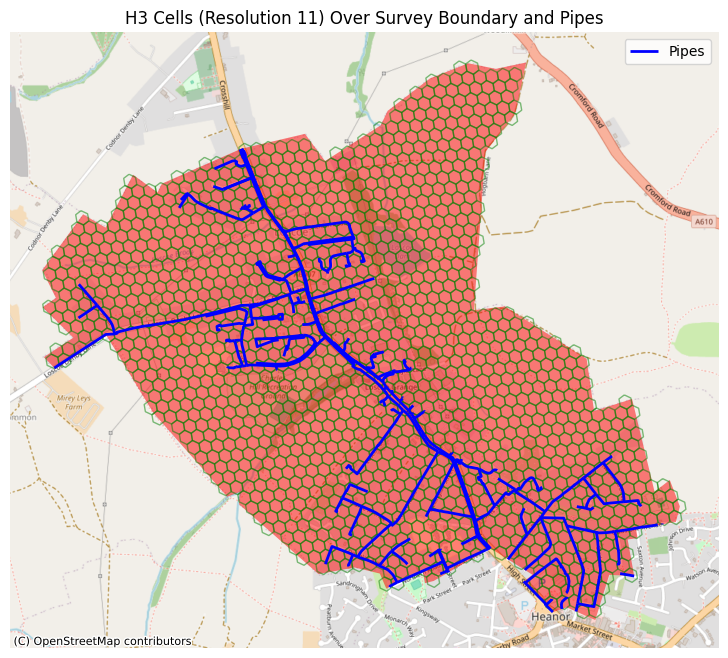

In [92]:
# Choose an H3 resolution (for example, 8 for neighborhood scale)
h3_resolution = 11
b = 5
# Convert the WKT geometry in 'geom' column of the first row to a Shapely object
boundary_geom = wkt.loads(survey.iloc[b]['boundary_geom'])

# H3 v4+: polygon_to_cells expects LatLngPoly/LatLngMultiPoly, not a GeoJSON dict.
# geo_to_cells accepts Shapely (via __geo_interface__) or a GeoJSON dict.
h3_cells = h3.geo_to_cells(boundary_geom, h3_resolution)

# List of cell index strings (order not guaranteed by h3)
h3_cells_list = list(h3_cells)

def h3_cell_polygon(cell):
    # Returns a shapely Polygon for an h3 cell index (in degrees)
    boundary = h3.cell_to_boundary(cell)
    # Invert lat and long (swap their positions in each tuple)
    boundary = [(lat, lon) for lon, lat in boundary]
    return Polygon(boundary)

# Create polygons for each H3 cell
h3_polys = [h3_cell_polygon(cell) for cell in h3_cells_list]
h3_gdf = gpd.GeoDataFrame({'h3_cell': h3_cells_list, 'geometry': h3_polys}, crs='EPSG:4326')
# Project h3_gdf to a projected CRS (e.g., Web Mercator) before buffering
h3_gdf_proj = h3_gdf.to_crs(epsg=3857)
h3_gdf_proj['offset'] = h3_gdf_proj['geometry'].buffer(-2)  # 2 meters in projected CRS (meters)

# For plotting, use the projected DataFrame with offset
h3_gdf_webmerc = h3_gdf_proj

# Optional: plot survey boundary as base
try:
    boundary_webmerc = gpd.GeoSeries([boundary_geom], crs='EPSG:4326').to_crs(epsg=3857)
except Exception:
    boundary_webmerc = None

# --- Overlap the pipes ---

# Get the WKT geometry of the pipes from the first row of 'survey'
pipes_geom = wkt.loads(survey.iloc[b]['pipes'])

# Convert pipes to GeoSeries and project to web mercator
pipes_webmerc = gpd.GeoSeries([pipes_geom], crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
if boundary_webmerc is not None:
    boundary_webmerc.plot(ax=ax, facecolor='red', alpha=0.5, linewidth=2, label='Boundary')
h3_gdf_webmerc.plot(ax=ax, facecolor='none', edgecolor='green', linewidth=1, alpha=0.5, label='H3 cells')
pipes_webmerc.plot(ax=ax, color='blue', linewidth=2, label='Pipes')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("H3 Cells (Resolution {}) Over Survey Boundary and Pipes".format(h3_resolution))
ax.set_axis_off()
plt.legend()
plt.show()

# Processing of the breadcrubs

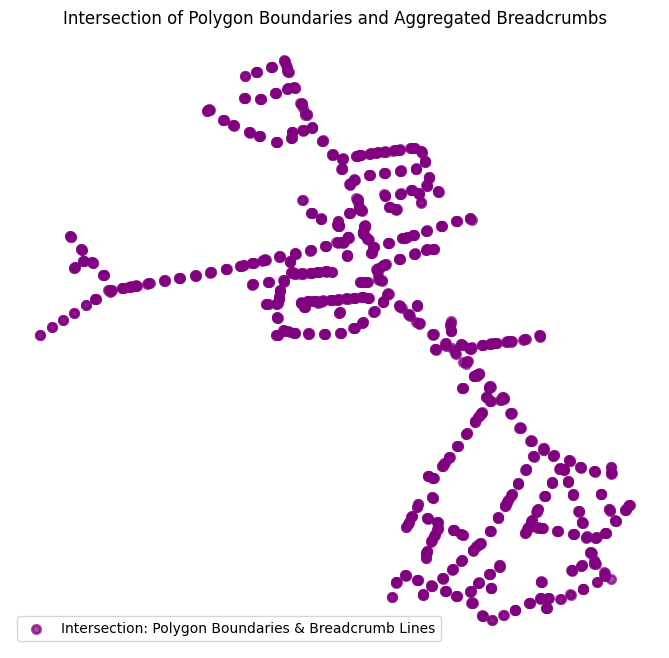

In [111]:
from shapely import wkt
from shapely.geometry import LineString, MultiLineString

# Get the aggregated breadcrumbs geometry (WKT or list of WKT)
agg_breadcrumbs = survey.iloc[b]["Aggregated_breadcrumbs"]

# If it's a string (WKT), convert to shapely, else if it's a list, parse each
if isinstance(agg_breadcrumbs, str):
    geom = wkt.loads(agg_breadcrumbs)
    agg_breadcrumbs_list = [geom]
elif isinstance(agg_breadcrumbs, list):
    # attempt to parse each WKT in the list to shapely
    agg_breadcrumbs_list = [wkt.loads(x) if isinstance(x, str) else x for x in agg_breadcrumbs]
else:
    # fallback for e.g., already a shapely geometry or MultiLineString etc
    agg_breadcrumbs_list = [agg_breadcrumbs]

# Make GeoDataFrame for aggregated breadcrumbs (assume they're still in EPSG:4326 to match original data)
agg_breadcrumbs_gdf = gpd.GeoDataFrame({"geometry": agg_breadcrumbs_list}, crs='EPSG:4326')
# Project them to match the projected CRS used for polygons/h3_gdf_proj
agg_breadcrumbs_gdf = agg_breadcrumbs_gdf.to_crs(epsg=3857)

# Create GeoDataFrame for the lines of the polygons (the boundaries of H3 cells)
# (Already in EPSG:3857)
polygon_lines = h3_gdf_proj.offset.boundary
polygon_lines_gdf = gpd.GeoDataFrame({"geometry": polygon_lines}, crs='EPSG:3857')

# Intersect the lines of the polygons with the breadcrumbs
intersection_gdf = gpd.overlay(polygon_lines_gdf, agg_breadcrumbs_gdf, how='intersection', keep_geom_type=False)

# Show head of the result
intersection_gdf.head()

# Plot the result
fig, ax = plt.subplots(figsize=(10, 8))
intersection_gdf.plot(ax=ax, color='purple', linewidth=2, alpha=0.7, label='Intersection: Polygon Boundaries & Breadcrumb Lines')
ax.set_title("Intersection of Polygon Boundaries and Aggregated Breadcrumbs")
ax.set_axis_off()
plt.legend()
plt.show()

In [ ]:
# Count how many points are inside the geometry of each cell in h3_gdf using the intersection results

# Assume the geometry for intersection_gdf are lines where the boundaries and breadcrumbs overlap.
# To count how many points (vertices) from the intersection_gdf lines fall inside each cell:

from shapely.geometry import Point

point_count_per_cell = []
h3_gdf_3857 = h3_gdf.to_crs(epsg=3857)
for cell_geom in h3_gdf_3857['geometry']:
    count = 0
    for geom in intersection_gdf['geometry']:
        if geom.is_empty:
            continue
        coords = []
        # Handle LineString, MultiLineString, and now also MultiPoint
        if geom.geom_type == "LineString":
            coords = list(geom.coords)
        elif geom.geom_type == "MultiLineString":
            coords = [pt for linestr in geom.geoms for pt in linestr.coords]
        elif geom.geom_type == "Point":
            coords = [(geom.x, geom.y)]
        elif geom.geom_type == "MultiPoint":
            coords = [(pt.x, pt.y) for pt in geom.geoms]
        else:
            continue
        for x, y in coords:
            if cell_geom.contains(Point(x, y)):
                count += 1
    point_count_per_cell.append(count)

# Add as a column to h3_gdf for reference
h3_gdf_3857['intersecting_points'] = point_count_per_cell

# Display the result
h3_gdf_3857[['intersecting_points']].head()ßßßßßßßßß

,intersecting_points
0,0
1,4
2,0
3,4
4,4


In [ ]:
h3_gdf_3857['intersecting_points'].value_counts()ß

intersecting_points
0     1183
4      178
6       42
2       40
8       12
10       3
12       1
Name: count, dtype: int64

In [110]:
import h3
# For each MultiPoint geometry in intersection_gdf, convert points to lat/lon and then to h3 cells
multipoint_to_h3_cells = []  # List to hold (orig_index, list_of_h3_cells) for each MultiPoint
resolution = 11 # Set your desired h3 resolution

for idx, geom in enumerate(intersection_gdf['geometry']):
    if geom.geom_type == "MultiPoint":
        h3_cells = []
        for pt in geom.geoms:
            # Convert coordinates to lat, lon order (shapely points are x=lon, y=lat)
            h3_cell = h3.latlng_to_cell(pt.y, pt.x, resolution)
            h3_cells.append(h3_cell)
        multipoint_to_h3_cells.append({'index': idx, 'h3_cells': h3_cells})

import geopandas as gpd
import pandas as pd
from shapely.geometry import MultiPoint

# Convert multipoint_to_h3_cells to a GeoDataFrame
# For each entry, make a MultiPoint geometry for visualization
records = []
for entry in multipoint_to_h3_cells:
    idx = entry['index']
    h3_cells = entry['h3_cells']
    # Optionally: include geometries for h3 cell centers for illustration
    points = []
    for h3_cell in h3_cells:
        lat, lon = h3.cell_to_latlng(h3_cell)
        points.append((lon, lat))  # Note (lon, lat) for shapely compatibility
    records.append({'index': idx, 'h3_cells': h3_cells, 'geometry': MultiPoint(points)})

multipoint_h3_gdf = gpd.GeoDataFrame(records, geometry='geometry', crs="EPSG:4326")
multipoint_h3_gdf

,index,h3_cells,geometry
0,0,"[8b0093d86c21fff, 8b0093181c09fff, 8b03a3822d3...","MULTIPOINT (84.97959 74.48563, 85.84100 74.891..."
1,1,"[8b9773b14670fff, 8b35464e90cafff, 8b35550e90d...","MULTIPOINT (26.52234 -20.63415, -17.99887 38.0..."
2,2,"[8bd0324ed0a5fff, 8bef5481eb93fff, 8bef55192a5...","MULTIPOINT (7.79742 -45.85658, -59.82355 -78.0..."
3,3,"[8b02c615ba1bfff, 8b02c05a68b3fff]","MULTIPOINT (-109.58833 72.04778, -108.61482 71..."
4,4,"[8b7ade2e096afff, 8b38158c2016fff, 8b528b0e249...","MULTIPOINT (41.69517 9.35091, -2.24907 32.6916..."
...,...,...,...
271,271,"[8b6b820b2129fff, 8be01a564771fff, 8be01a570b2...","MULTIPOINT (17.68199 6.73960, 61.61057 -55.187..."
272,272,"[8b00c9482351fff, 8b006a289c93fff, 8b006a21835...","MULTIPOINT (126.45926 87.93446, -24.78705 83.0..."
273,273,"[8b398031dc6bfff, 8b399db2650afff, 8b2d6175b61...","MULTIPOINT (-8.89878 31.96483, -7.39529 30.824..."
274,274,"[8b0a6688b813fff, 8b0b5b2612f6fff]","MULTIPOINT (85.49792 70.95610, 86.17098 70.44582)"


/tmp/ipykernel_18331/2220796258.py:6: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


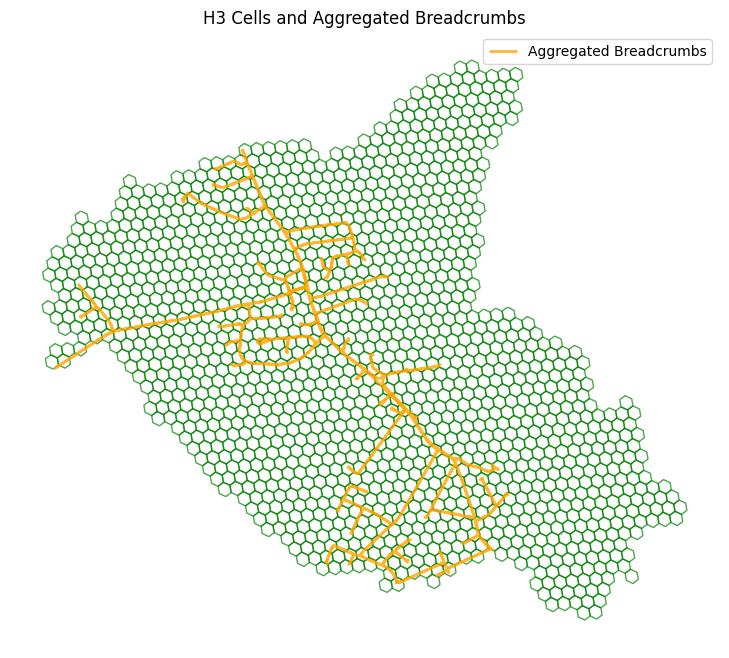

In [55]:
fig, ax = plt.subplots(figsize=(10, 8))
h3_gdf.plot(ax=ax, facecolor='none', edgecolor='green', linewidth=1, alpha=0.7, label='H3 cells')
agg_breadcrumbs_gdf.plot(ax=ax, color='orange', linewidth=2, alpha=0.8, label='Aggregated Breadcrumbs')
ax.set_title("H3 Cells and Aggregated Breadcrumbs")
ax.set_axis_off()
plt.legend()
plt.show()

In [43]:
join_gdf['index_right'].dropna().unique()

array([0.])

# Processing of the piepes

In [16]:
from shapely import wkt
from shapely.geometry import MultiLineString, LineString

# Convert pipes WKT to geometry
pipes_geom = wkt.loads(df.iloc[0]['pipes'])

# Ensure geometry is MultiLineString
if isinstance(pipes_geom, LineString):
    pipes_geom = MultiLineString([pipes_geom])

# Make a GeoDataFrame for the pipes
pipes_gdf = gpd.GeoDataFrame({'geometry': [pipes_geom]}, crs="EPSG:4326")

# Intersection: clip pipes within the boundary polygon
pipes_in_boundary = gpd.overlay(pipes_gdf, h3_gdf, how='intersection')

# pipes_in_boundary now contains only the part of the pipes within the area


In [17]:
# Calculate the km of pipes in each h3 cell using the geometry in pipes_in_boundary
# Project to a metric CRS (Web Mercator) to compute lengths
pipes_in_boundary_m = pipes_in_boundary.to_crs(epsg=3857)
pipes_in_boundary['pipe_km'] = pipes_in_boundary_m.geometry.length / 1000  # km

In [18]:
pipes_in_boundary.head()

,h3_cell,geometry,pipe_km


/tmp/ipykernel_18331/951573720.py:5: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  pipes_in_boundary.to_crs(epsg=3857).plot(
/tmp/ipykernel_18331/951573720.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


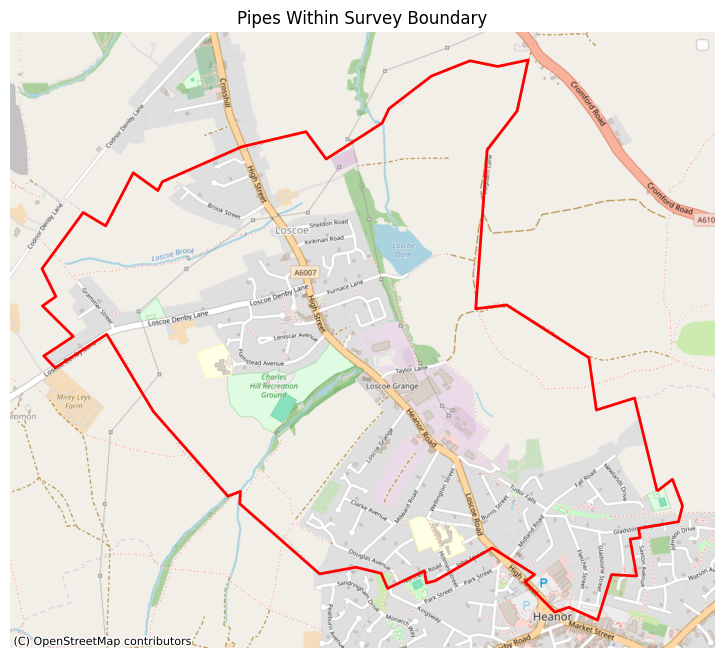

In [19]:
# Plot the pipes within the boundary polygon

fig, ax = plt.subplots(figsize=(10, 8))
# Plot the pipes clipped to the boundary in blue
pipes_in_boundary.to_crs(epsg=3857).plot(
    ax=ax, 
    color='blue', 
    linewidth=2, 
    label='Pipes in Boundary'
)
# Optionally, plot the survey boundary for reference if available
if boundary_webmerc is not None:
    boundary_webmerc.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Boundary')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Pipes Within Survey Boundary")
ax.set_axis_off()
plt.legend()
plt.show()

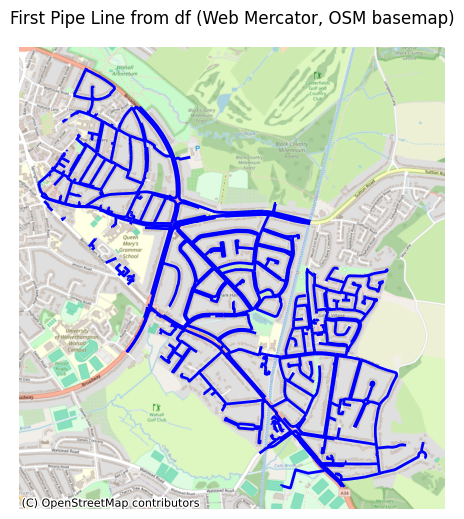

In [20]:

# Convert the WKT string in the 'pipes' column of the first row to a Shapely geometry
first_line_geom = wkt.loads(df.iloc[0]['pipes'])

# Create a GeoDataFrame for the first line, specify CRS as WGS84 (EPSG:4326)
first_line_gdf = gpd.GeoDataFrame({'geometry': [first_line_geom]}, crs='EPSG:4326')

# Project to Web Mercator (EPSG:3857) for compatibility with basemaps
first_line_webmerc = first_line_gdf.to_crs(epsg=3857)

# Plot with basemap
fig, ax = plt.subplots(figsize=(8, 6))
first_line_webmerc.plot(ax=ax, color='blue', linewidth=2)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("First Pipe Line from df (Web Mercator, OSM basemap)")
ax.set_axis_off()
plt.show()

In [21]:
intersect_query = f"""
SELECT 
    ST_AsText(v.geom) as geom
FROM xchange.v_boundary_cadent_2026_4326 v
WHERE v.externalid IN (SELECT DISTINCT boundaryname FROM temp_survey)
"""



## Parititon the breadcrunb trajectory into H3 cells count the number of breadcrumbs of each cell
## Find the closest pipe to

